## Importación de librerías

In [4]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

#Forzar tema claro
%matplotlib inline
sns.set_theme()

## Carga, agregación a 30 días y purga de datos sensibles

In [5]:
# 1. Cargar datos
vle_df = pd.read_csv('./../../../dataset/oulad/studentVle.csv')
info_df = pd.read_csv('./../../../dataset/oulad/studentInfo.csv')

# 2. Extraer comportamiento de los primeros 30 días
vle_30_days = vle_df[vle_df['date'] <= 30]
vle_agg = vle_30_days.groupby(['id_student', 'code_module', 'code_presentation']).agg(
    total_clicks=('sum_click', 'sum'),
    mean_clicks=('sum_click', 'mean'),
    active_days=('date', 'nunique')
).reset_index()

vle_agg.fillna(0, inplace=True)

# 3. Excluir datos sensibles
sensitive_columns = ['gender', 'disability', 'age_band', 'imd_band', 'region']
info_clean = info_df.drop(columns=sensitive_columns)

## Cruce de datos y creación del Target

In [6]:
# 1. Mergear datos
df_merged = pd.merge(info_clean, vle_agg, on=['id_student', 'code_module', 'code_presentation'], how='inner')

# 2. Definir Agotamiento (Withdrawn = 1, Resto = 0)
df_merged['target_burnout'] = df_merged['final_result'].apply(lambda x: 1 if x == 'Withdrawn' else 0)

# Limpiar columnas innecesarias
df_merged = df_merged.drop(columns=['final_result', 'id_student'])

## Partición por cursos

In [7]:
# Entrenamos con 2013
df_train = df_merged[df_merged['code_presentation'].str.contains('2013')].copy()

# Evaluamos con 2014
df_test = df_merged[df_merged['code_presentation'].str.contains('2014')].copy()

# Limpiar metadatos e identificadores
columnas_a_borrar = ['code_module', 'code_presentation']

# Separar matriz de características (X) y variable objetivo (y)
X_train = df_train.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_train = df_train['target_burnout']

X_test = df_test.drop(columns=columnas_a_borrar + ['target_burnout'], errors='ignore')
y_test = df_test['target_burnout']

print(f"Alumnos en Histórico (Train 2013): {len(X_train)}")
print(f"Alumnos Nuevos (Test 2014): {len(X_test)}")

Alumnos en Histórico (Train 2013): 12049
Alumnos Nuevos (Test 2014): 16793


## Construcción y Entrenamiento del Pipeline

In [8]:


# 1. Definición de columnas
cat_cols = ['highest_education']
num_cols = ['num_of_prev_attempts', 'studied_credits', 'total_clicks', 'mean_clicks', 'active_days']

# 2. Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ])

# 3. Pipeline Base KNN
knn_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(n_neighbors=5, weights='uniform', n_jobs=-1))
])

# 4. Entrenar modelo
knn_pipeline.fit(X_train, y_train)

# 5. Generar predicciones
y_pred = knn_pipeline.predict(X_test)

## Evaluación y Gráficas de Rendimiento

--- REPORTE DE CLASIFICACIÓN DETALLADO (KNN) ---
              precision    recall  f1-score   support

           0       0.75      0.92      0.83     12285
           1       0.45      0.17      0.24      4508

    accuracy                           0.72     16793
   macro avg       0.60      0.55      0.54     16793
weighted avg       0.67      0.72      0.67     16793



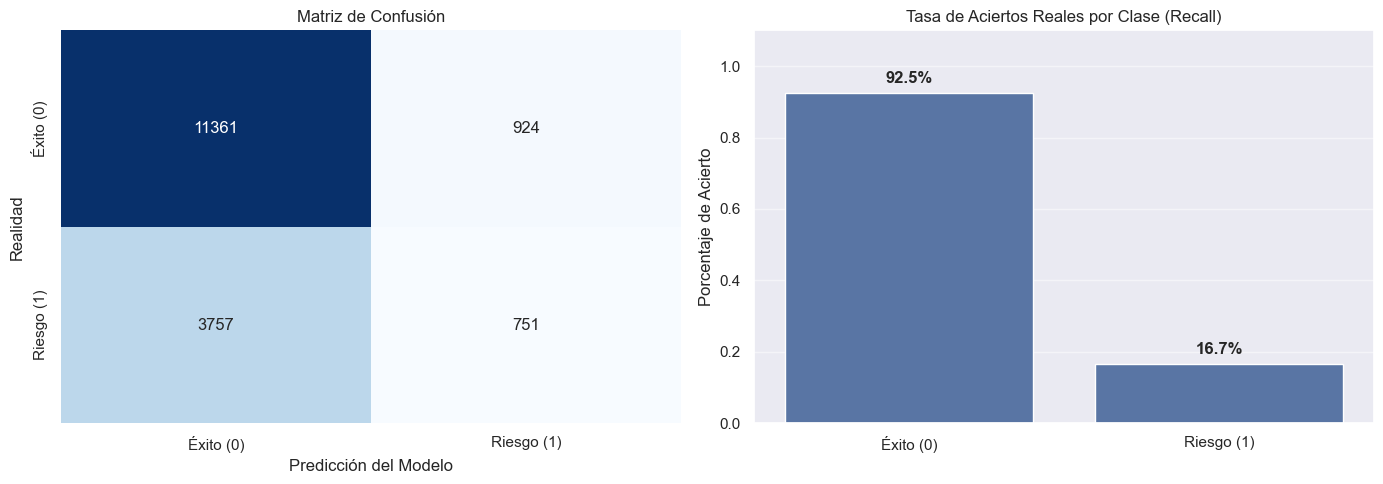

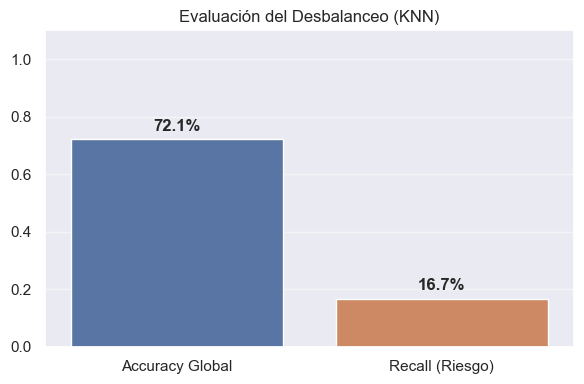

In [9]:


#Metricas
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("--- REPORTE DE CLASIFICACIÓN DETALLADO (KNN) ---")
print(classification_report(y_test, y_pred, zero_division=0))

#Ploters
cm = confusion_matrix(y_test, y_pred)
hit_rates = cm.diagonal() / cm.sum(axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#Matriz de Confusión
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax1,
            xticklabels=['Éxito (0)', 'Riesgo (1)'],
            yticklabels=['Éxito (0)', 'Riesgo (1)'])
ax1.set_title('Matriz de Confusión')
ax1.set_xlabel('Predicción del Modelo')
ax1.set_ylabel('Realidad')

#Tasa de Aciertos (Recall) por Clase
sns.barplot(x=['Éxito (0)', 'Riesgo (1)'], y=hit_rates, ax=ax2)
ax2.set_title('Tasa de Aciertos Reales por Clase (Recall)')
ax2.set_ylabel('Porcentaje de Acierto')
ax2.set_ylim(0, 1.1)

for i, v in enumerate(hit_rates):
    ax2.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

#acuracy vs recall
report_dict = classification_report(y_test, y_pred, output_dict=True, zero_division=0)
burnout_recall = report_dict['1']['recall']

plt.figure(figsize=(6, 4))
metric_names_comp = ['Accuracy Global', 'Recall (Riesgo)']
metric_values_comp = [acc, burnout_recall]

ax3 = sns.barplot(x=metric_names_comp, y=metric_values_comp, hue=metric_names_comp, legend=False)
plt.title('Evaluación del Desbalanceo (KNN)')
plt.ylim(0, 1.1)

for i, v in enumerate(metric_values_comp):
    ax3.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()